In [1]:
import torch
import numpy as np
import pandas as pd

In [22]:
# 已经是处理好之后的数据，用torch.load读取出来即可
X_train, y_train = torch.load("/Users/ikunchuan/Desktop/python_learning/dl/卷积网络实战/data/MNIST/processed/training.pt")
X_test, y_test = torch.load("/Users/ikunchuan/Desktop/python_learning/dl/卷积网络实战/data/MNIST/processed/test.pt")

In [23]:
X_train[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [24]:
y_train

tensor([5, 0, 4,  ..., 5, 6, 8])

In [25]:
print(X_train.shape, X_train.dtype)

torch.Size([60000, 28, 28]) torch.uint8


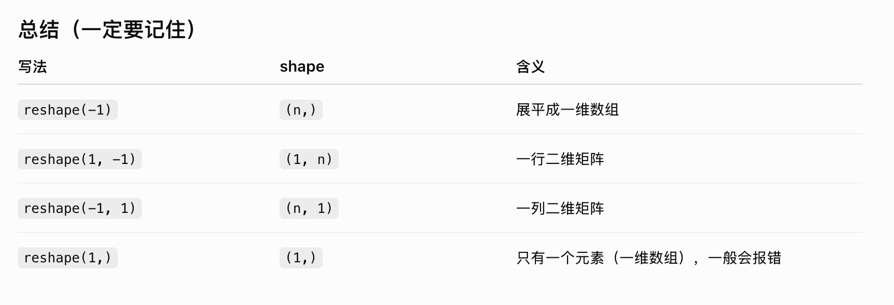

In [26]:
# 把它展开成28*28=784维的向量
X_train = X_train.reshape(-1,784).float()/255.0
print(X_train.shape)

torch.Size([60000, 784])


In [27]:
print(X_train.shape, X_train.dtype, X_train.min().item(), X_train.max().item())

torch.Size([60000, 784]) torch.float32 0.0 1.0


In [28]:
X_test = X_test.reshape(-1, 784).float() / 255.0
print(X_test.shape)

torch.Size([10000, 784])


In [29]:
# 数据处理完了，接下来定义模型参数

num_inputs = 784
num_classes = 10

# 随机初始化 W
W = torch.normal(0, 0.01, size=(num_inputs, num_classes), requires_grad=True)
# 把 b 全设置成0
b = torch.zeros(num_classes, requires_grad=True)

print(W.shape, b.shape)

torch.Size([784, 10]) torch.Size([10])


In [46]:
# 接下来定义softmax函数

def softmax(X):
    X = X - X.max(dim=1, keepdim=True).values  # 数值稳定 防止exp(X)溢出
    X_exp = X.exp()
    return X_exp / X_exp.sum(dim=1, keepdim=True)

def forward(X):
    y_hat = X @ W + b
    return softmax(y_hat)

def loss_function(y_hat, y):
    return -torch.log(y_hat[range(len(y)), y]).mean()  # 这里没有使用one-hot编码，不需要，使用y_hat[range(len(y),y)]就可以达到同样的目的，并且更加简洁



In [47]:
y_hat = forward(X_train[:10])
print(y_hat.shape)
print(y_hat[:2])          # 打印前两个样本的 10 类概率
print(y_hat.sum(dim=1))   # 每行概率和应该为 1

torch.Size([10, 10])
tensor([[0.0876, 0.1044, 0.1108, 0.1078, 0.0981, 0.0918, 0.0935, 0.1051, 0.0962,
         0.1048],
        [0.0821, 0.1146, 0.1101, 0.0982, 0.0924, 0.0890, 0.1081, 0.0972, 0.0971,
         0.1112]], grad_fn=<SliceBackward0>)
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000], grad_fn=<SumBackward1>)


In [48]:
# 接下来定义准确率计算和训练循环。先写准确率

def accuracy(y_hat, y):
    pred = y_hat.argmax(dim=1)
    return (pred == y).float().mean()

In [49]:
# 然后设置超参数和优化器:

lr = 0.1
num_epochs = 10
batch_size = 256

optimizer = torch.optim.SGD([W, b], lr=lr)

In [50]:
for epoch in range(num_epochs):
    # 打乱数据
    perm = torch.randperm(len(X_train))

    for i in range(0, len(X_train), batch_size):
        idx = perm[i:i+batch_size]
        X_batch = X_train[idx]
        y_batch = y_train[idx]

        # 前向
        y_hat = forward(X_batch)
        loss = loss_function(y_hat, y_batch)

        # 反向
        optimizer.zero_grad()
        loss.backward()     # 自动从 loss 一路反向传播，算出所有参数的梯度
        optimizer.step()    # 自动根据梯度更新参数

    # 每个 epoch 结束后看训练和测试准确率
    with torch.no_grad():
        train_acc = accuracy(forward(X_train), y_train)
        test_acc = accuracy(forward(X_test), y_test)
    print(f'epoch {epoch+1:2d}, loss {loss.item():.4f}, train acc {train_acc:.3f}, test acc {test_acc:.3f}')

epoch  1, loss 0.5050, train acc 0.880, test acc 0.888
epoch  2, loss 0.4434, train acc 0.892, test acc 0.899
epoch  3, loss 0.3579, train acc 0.899, test acc 0.906
epoch  4, loss 0.2854, train acc 0.904, test acc 0.908
epoch  5, loss 0.3937, train acc 0.906, test acc 0.911
epoch  6, loss 0.2676, train acc 0.908, test acc 0.914
epoch  7, loss 0.3305, train acc 0.911, test acc 0.915
epoch  8, loss 0.3710, train acc 0.911, test acc 0.916
epoch  9, loss 0.2203, train acc 0.913, test acc 0.917
epoch 10, loss 0.2156, train acc 0.915, test acc 0.918


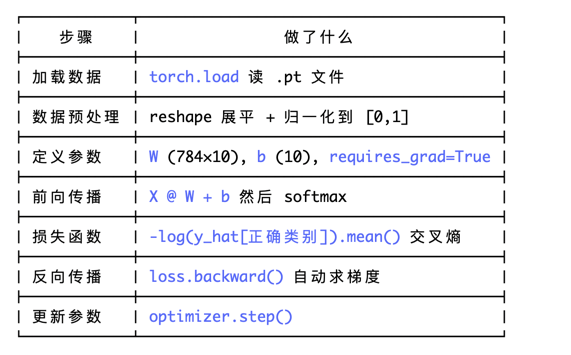